## Machine Learning Project Phase 2.0 ( Predicting House Prices )



In [1]:
# Imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
# Configurations
RANDOM_STATE = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.10
TEST_RATIO = 0.20

# Paths 

DATASET_PATH = 'Final Datasets/AmesHousing.csv'

In [3]:
#Load Dataset

df = pd.read_csv(DATASET_PATH)
print(f"Successfully loaded {DATASET_PATH}")

target_col = 'SalePrice'
if target_col not in df.columns:
    raise ValueError("Target column missing from dataset.")

y = df[target_col]
X = df.drop(columns=[target_col])
print(f"Features: {X.shape[1]}, Records: {X.shape[0]}")

Successfully loaded Final Datasets/AmesHousing.csv
Features: 81, Records: 2930


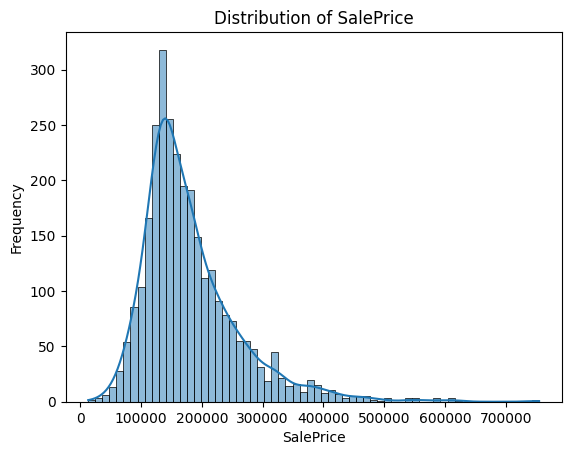

In [4]:
# TODO: Quick EDA (Target Histogram)

sns.histplot(y, kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

In [5]:
# Preprocessing (Imputation, Transformation, Encoding, Scaling)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

num_imputer = SimpleImputer(strategy='median')
X_num = pd.DataFrame(num_imputer.fit_transform(X[num_cols]), columns=num_cols, index=X.index)
X_cat = X[cat_cols].fillna('Missing').copy() if cat_cols else pd.DataFrame(index=X.index)

skew = X_num.skew().abs().sort_values(ascending=False)
skewed_cols = skew[skew > 0.75].index.tolist()
for column in skewed_cols:
    X_num[f'{column}_log'] = np.log1p(np.maximum(X_num[column], 0))

embedding_frames = []
embedding_dim = 3
top_categories = 30

for col in cat_cols:
    col_data = X_cat[col].astype(str)
    if col_data.nunique() > top_categories:
        popular = col_data.value_counts().index[:top_categories]
        col_data = col_data.where(col_data.isin(popular), other='Other')
    dummies = pd.get_dummies(col_data, prefix=col, drop_first=False)
    if dummies.shape[1] <= 1:
        continue
    n_components = min(embedding_dim, dummies.shape[1] - 1)
    if n_components < 1:
        continue
    svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    embedded = svd.fit_transform(dummies)
    embed_cols = [f"{col}_embed_{i+1}" for i in range(n_components)]
    embedding_frames.append(pd.DataFrame(embedded, columns=embed_cols, index=X.index))

X_cat_embed = pd.concat(embedding_frames, axis=1) if embedding_frames else pd.DataFrame(index=X.index)

X_proc = pd.concat([X_num, X_cat_embed], axis=1).fillna(0)

valid_idx = y.dropna().index
y_valid = y.loc[valid_idx]
y_target = np.log1p(y_valid)

feature_corr_signed = (
    X_proc.loc[valid_idx]
    .corrwith(y_target)
    .dropna()
 )
feature_corr = feature_corr_signed.abs().sort_values(ascending=False)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_proc.loc[valid_idx]),
    columns=X_proc.columns,
    index=valid_idx
 )

full_corr_matrix = X_scaled.corr()
target_corr_full = X_scaled.corrwith(y_target)

X_final = X_scaled
y_final = y_target

print(f"Numeric features: {X_num.shape[1]}")
print(f"Categorical embedding features: {X_cat_embed.shape[1]}")
print(f"Total processed features used: {X_final.shape[1]}")
print("Top correlated feature sample:", feature_corr.index[:5].tolist())

Numeric features: 60
Categorical embedding features: 121
Total processed features used: 181
Top correlated feature sample: ['Overall Qual', 'Gr Liv Area_log', 'Gr Liv Area', 'Garage Cars', 'Garage Area']


In [6]:
# Train-Test Split and K-Fold Cross-Validation

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    shuffle=True
 )

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"CV folds: {kfold.get_n_splits()}")

Train samples: 2344, Test samples: 586
CV folds: 5


In [7]:
# Models Pipelines and Hyperparameter Grids

models_config = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {
            'fit_intercept': [True, False],
            'positive': [False, True]
        }
    },
    "ElasticNet": {
        "model": ElasticNet(max_iter=5000, random_state=RANDOM_STATE),
        "params": {
            'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
        }
    },
    "MLP Regressor": {
        "model": MLPRegressor(max_iter=1000, early_stopping=True, random_state=RANDOM_STATE),
        "params": {
            'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.001, 0.01, 0.1],
            'learning_rate_init': [0.0005, 0.001, 0.003, 0.01],
            'batch_size': ['auto', 64, 128]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.03, 0.05, 0.1],
            'max_depth': [3, 4, 5],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 3],
            'subsample': [0.7, 0.85, 1.0],
            'max_features': [None, 'sqrt', 'log2']
        }
    }
}
print(f"Configured {len(models_config)} models with {kfold.get_n_splits()}-fold CV")

Configured 4 models with 5-fold CV


In [8]:
# Training, Hyperparameter Tuning, and Evaluation

results = []
predictions_dict = {}

print("\n--- Starting Training ---")
for name, config in models_config.items():
    print(f"Training {name}...")
    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=kfold,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({
        "Model": name,
        "MSE": mse,
        "R2": r2,
        "Best Params": grid.best_params_
    })
    predictions_dict[name] = preds

results_df = pd.DataFrame(results).sort_values(by="MSE")
print("\n==================================================")
print("FINAL MODEL COMPARISON")
print("==================================================")
print(results_df[["Model", "MSE", "R2"]].to_string(index=False))
print("--------------------------------------------------")

print("Best hyperparameters per model:")
for entry in results:
    print(f"- {entry['Model']}: {entry['Best Params']}")

best_model_name = results_df.iloc[0]["Model"]
print(f"The Best Model is: {best_model_name}")




--- Starting Training ---
Training Linear Regression...
Training ElasticNet...
Training MLP Regressor...
Training Gradient Boosting...

FINAL MODEL COMPARISON
            Model      MSE       R2
Gradient Boosting 0.010668 0.942345
Linear Regression 0.013682 0.926054
       ElasticNet 0.013780 0.925524
    MLP Regressor 0.016741 0.909524
--------------------------------------------------
Best hyperparameters per model:
- Linear Regression: {'fit_intercept': True, 'positive': False}
- ElasticNet: {'alpha': 0.05, 'l1_ratio': 0.1}
- MLP Regressor: {'activation': 'tanh', 'alpha': 0.1, 'batch_size': 64, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01}
- Gradient Boosting: {'learning_rate': 0.03, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 1.0}
The Best Model is: Gradient Boosting


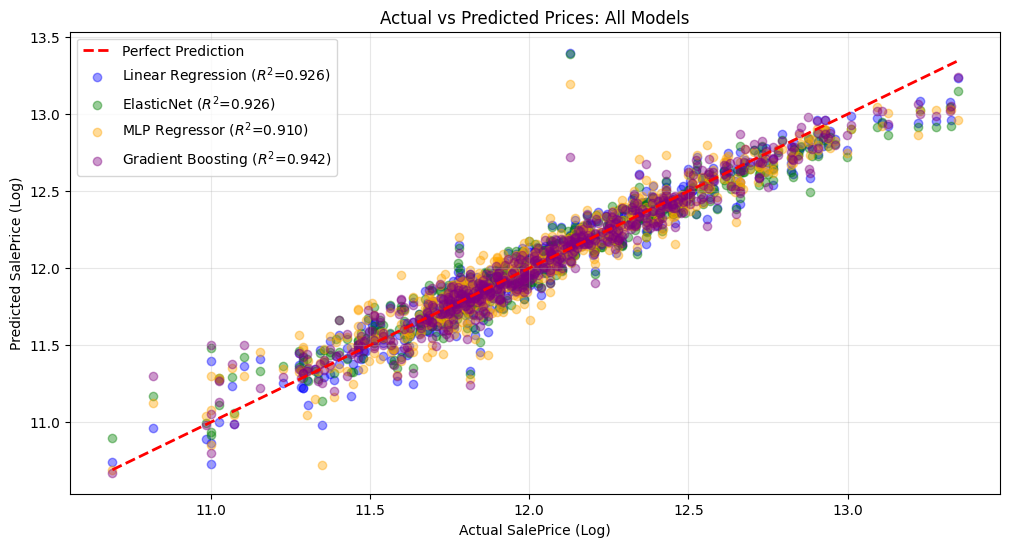

In [10]:
# Plotting and Visualization

plt.figure(figsize=(12, 6))
colors = {
    'Linear Regression': 'blue',
    'ElasticNet': 'green',
    'MLP Regressor': 'orange',
    'Gradient Boosting': 'purple',
}
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
for name, preds in predictions_dict.items():
    r2_val = results_df[results_df["Model"] == name]["R2"].values[0]
    plt.scatter(y_test, preds, alpha=0.4, label=f'{name} ($R^2$={r2_val:.3f})', color=colors.get(name, 'gray'))
plt.xlabel('Actual SalePrice (Log)')
plt.ylabel('Predicted SalePrice (Log)')
plt.title('Actual vs Predicted Prices: All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()